In [623]:
import numpy as np

In [624]:
import pandas as pd

In [625]:
import matplotlib.pyplot as plt

In [626]:
from sklearn.model_selection import train_test_split, StratifiedKFold

In [627]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier

In [628]:
from imblearn.over_sampling import SMOTE

In [629]:
from sklearn.feature_selection import SelectKBest, f_classif

In [630]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,mean_squared_error,roc_auc_score,roc_curve
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import fbeta_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import matthews_corrcoef
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import XGBClassifier

In [631]:
import tensorflow as tf

In [632]:
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [633]:
from tensorflow.keras.utils import to_categorical

In [634]:
from tensorflow.keras.models import Sequential

print("Libraries imported successfully!")

Libraries imported successfully!


In [635]:
%matplotlib inline

In [636]:
data = pd.read_csv('../data/creditcardcsvpresent.csv')

In [637]:
data.columns

Index(['Merchant_id', 'Transaction date', 'Average Amount/transaction/day',
       'Transaction_amount', 'Is declined', 'Total Number of declines/day',
       'isForeignTransaction', 'isHighRiskCountry', 'Daily_chargeback_avg_amt',
       '6_month_avg_chbk_amt', '6-month_chbk_freq', 'isFradulent'],
      dtype='object')

In [638]:
data.head(3)

,Merchant_id,Transaction date,Average Amount/transaction/day,Transaction_amount,Is declined,Total Number of declines/day,isForeignTransaction,isHighRiskCountry,Daily_chargeback_avg_amt,6_month_avg_chbk_amt,6-month_chbk_freq,isFradulent
0,3160040998,NaN,100.0,3000.0,N,5,Y,Y,0,0.0,0,Y
1,3160040998,NaN,100.0,4300.0,N,5,Y,Y,0,0.0,0,Y
2,3160041896,NaN,185.5,4823.0,Y,5,N,N,0,0.0,0,Y


In [639]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3075 entries, 0 to 3074
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Merchant_id                     3075 non-null   int64  
 1   Transaction date                0 non-null      float64
 2   Average Amount/transaction/day  3075 non-null   float64
 3   Transaction_amount              3075 non-null   float64
 4   Is declined                     3075 non-null   object 
 5   Total Number of declines/day    3075 non-null   int64  
 6   isForeignTransaction            3075 non-null   object 
 7   isHighRiskCountry               3075 non-null   object 
 8   Daily_chargeback_avg_amt        3075 non-null   int64  
 9   6_month_avg_chbk_amt            3075 non-null   float64
 10  6-month_chbk_freq               3075 non-null   int64  
 11  isFradulent                     3075 non-null   object 
dtypes: float64(4), int64(4), object(4)

In [640]:
data.describe()

,Merchant_id,Transaction date,Average Amount/transaction/day,Transaction_amount,Total Number of declines/day,Daily_chargeback_avg_amt,6_month_avg_chbk_amt,6-month_chbk_freq
count,3.075000e+03,0.0,3075.000000,3075.000000,3075.000000,3075.000000,3075.000000,3075.000000
mean,5.026634e+09,NaN,515.026556,9876.399210,0.957398,55.737561,40.022407,0.391870
std,9.870778e+08,NaN,291.906978,10135.331016,2.192391,206.634779,155.968840,1.548479
min,3.160041e+09,NaN,4.011527,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.170814e+09,NaN,269.788047,2408.781147,0.000000,0.000000,0.000000,0.000000
50%,5.025578e+09,NaN,502.549575,6698.891856,0.000000,0.000000,0.000000,0.000000
75%,5.889625e+09,NaN,765.272803,14422.568935,0.000000,0.000000,0.000000,0.000000
max,6.665906e+09,NaN,2000.000000,108000.000000,20.000000,998.000000,998.000000,9.000000


In [641]:
data.isna().sum()

Merchant_id                          0
Transaction date                  3075
Average Amount/transaction/day       0
Transaction_amount                   0
Is declined                          0
Total Number of declines/day         0
isForeignTransaction                 0
isHighRiskCountry                    0
Daily_chargeback_avg_amt             0
6_month_avg_chbk_amt                 0
6-month_chbk_freq                    0
isFradulent                          0
dtype: int64

In [642]:
data.isnull().sum()

Merchant_id                          0
Transaction date                  3075
Average Amount/transaction/day       0
Transaction_amount                   0
Is declined                          0
Total Number of declines/day         0
isForeignTransaction                 0
isHighRiskCountry                    0
Daily_chargeback_avg_amt             0
6_month_avg_chbk_amt                 0
6-month_chbk_freq                    0
isFradulent                          0
dtype: int64

In [643]:
# Remove duplicates
data = data.drop_duplicates()

In [644]:
print(data.columns)

Index(['Merchant_id', 'Transaction date', 'Average Amount/transaction/day',
       'Transaction_amount', 'Is declined', 'Total Number of declines/day',
       'isForeignTransaction', 'isHighRiskCountry', 'Daily_chargeback_avg_amt',
       '6_month_avg_chbk_amt', '6-month_chbk_freq', 'isFradulent'],
      dtype='object')


In [645]:

# Nettoyage des noms de colonnes (suppression des espaces et conversion en minuscules)
data.columns = data.columns.str.strip().str.lower()

In [646]:
print(data.columns)

Index(['merchant_id', 'transaction date', 'average amount/transaction/day',
       'transaction_amount', 'is declined', 'total number of declines/day',
       'isforeigntransaction', 'ishighriskcountry', 'daily_chargeback_avg_amt',
       '6_month_avg_chbk_amt', '6-month_chbk_freq', 'isfradulent'],
      dtype='object')


/var/folders/9r/15bm4lk93l149ljbx85kxz_h0000gn/T/ipykernel_28930/4266551294.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].replace({'N': 0, 'Y': 1}).astype(int)  # Convertir les 'N'/'Y' en 0/1
/var/folders/9r/15bm4lk93l149ljbx85kxz_h0000gn/T/ipykernel_28930/4266551294.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].replace({'N': 0, 'Y': 1}).astype(int)  # Convertir les 'N'/'Y' en 0/1
/var/folders/9r/15bm4lk93l149ljbx85kxz_h0000gn/T/ipykernel_28930/4266551294.py:27: FutureWarni

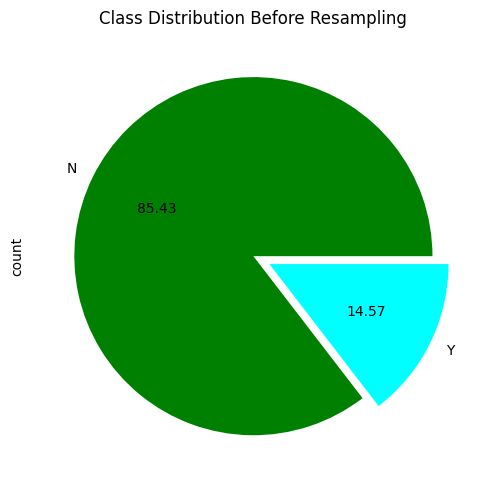

In [647]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# 2. Transformation des montants financiers
scaler = StandardScaler()
amount_cols = ['transaction_amount', 'average amount/transaction/day', 'daily_chargeback_avg_amt', '6_month_avg_chbk_amt']

for col in amount_cols:
    if col in data.columns:
        data[col] = scaler.fit_transform(data[[col]])

# 3. Ingénierie des Features
# Conversion de la date en datetime
if 'transaction date' in data.columns:
    data['transaction date'] = pd.to_datetime(data['transaction date'])
    data['transaction_hour'] = data['transaction date'].dt.hour
    data['transaction_dayofweek'] = data['transaction date'].dt.dayofweek

# 4. Encodage des variables binaires (remplacement de 'N' et 'Y' par 0 et 1)
binary_cols = ['is declined', 'isforeigntransaction', 'ishighriskcountry']

for col in binary_cols:
    if col in data.columns:
        data[col] = data[col].replace({'N': 0, 'Y': 1}).astype(int)  # Convertir les 'N'/'Y' en 0/1


# 1. Visualisation de la distribution des classes avant équilibrage
plt.figure(figsize=(5, 5))
data["isfradulent"].value_counts().plot.pie(autopct="%.2f", colors=["green","cyan"], explode=[0, 0.1])
plt.title("Class Distribution Before Resampling")
plt.tight_layout()
plt.show()


# Train test and split

In [648]:
# Convertir transaction_date en timestamp (secondes depuis Epoch)
if 'transaction date' in data.columns:
    data['transaction_timestamp'] = pd.to_datetime(data['transaction date']).astype(int) // 10**9  # Convertir en secondes

# Supprimer l'ancienne colonne datetime
data = data.drop(columns=['transaction date'])

# Min-Max Normalization sur les colonnes numériques
numeric_features = data.select_dtypes(include=['number']).columns
data[numeric_features] = data[numeric_features].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# Remplacer NaN par 0
data = data.fillna(0)


In [649]:
labelencoder = LabelEncoder()
data.iloc[:, -1] = labelencoder.fit_transform(data.iloc[:, -1])
#X = data.drop([' Label'], axis=1).values
#Y = data.iloc[:, -1].values.reshape(-1,1)
#Y = np.ravel(Y)
X = data.drop('isfradulent', axis=1)
Y = data['isfradulent']
Y = labelencoder.fit_transform(Y)  # Ensure consistent encoding
print("Encoded classes:", labelencoder.classes_)

Encoded classes: ['N' 'Y']


In [650]:
import numpy as np
import pandas as pd
from river import drift
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# # =====================================================
# # 1. Load and prepare dataset
# # =====================================================
# # Example: Uncomment and adapt if loading from file
# # data = pd.read_csv("synthetic_creditcard.csv")

# # Ensure column names are correct
# # features = [
# #     'Merchant_id', 'Transaction date', 'Average Amount/transaction/day',
# #     'Transaction_amount', 'Is declined', 'Total Number of declines/day',
# #     'isForeignTransaction', 'isHighRiskCountry', 'Daily_chargeback_avg_amt',
# #     '6_month_avg_chbk_amt', '6-month_chbk_freq'
# # ]
# # target = 'isFradulent'

# # X = data[features]
# # Y = data[target]

# # =====================================================
# # 2. Preprocessing
# # =====================================================
# # Convert categorical columns to numeric using one-hot encoding
# X = pd.get_dummies(X, drop_first=True)

# # Ensure target is a Series (if it’s an array, wrap it)
# if isinstance(Y, np.ndarray):
#     Y = pd.Series(Y, name="isFradulent")

# # Convert to numpy for streaming
# X_stream = X.values
# y_stream = Y.values
# indices = np.arange(len(y_stream))

# # =====================================================
# # 3. Initialize online drift detectors
# # =====================================================
# adwin = drift.ADWIN()
# kswin = drift.KSWIN(alpha=0.001, window_size=200)
# ph = drift.PageHinkley(delta=0.005, threshold=50, alpha=0.999)

# adwin_drifts, kswin_drifts, ph_drifts = [], [], []
# clean_data_indices = []  # Indices of stable (non-drift) samples

# # =====================================================
# # 4. Simulate streaming with detection and removal
# # =====================================================
# for i, label in enumerate(y_stream):

#     # Update each detector with the target label
#     adwin.update(label)
#     kswin.update(label)
#     ph.update(label)

#     drift_detected = False

#     if adwin.drift_detected:
#         adwin_drifts.append(i)
#         #adwin.reset()
#         drift_detected = True

#     if kswin.drift_detected:
#         kswin_drifts.append(i)
#         # kswin.reset()  <-- REMOVE this line
#         drift_detected = True

#     if ph.drift_detected:
#         ph_drifts.append(i)
#         #ph.reset()
#         drift_detected = True

#     # Keep data if stable (no drift)
#     if not drift_detected:
#         clean_data_indices.append(i)

# # =====================================================
# # 5. Create "drift-free" cleaned dataset
# # =====================================================
# X_clean = X.iloc[clean_data_indices]
# y_clean = Y.iloc[clean_data_indices]

# print(f"✅ Cleaned dataset size: {X_clean.shape[0]} / {len(Y)} ({100 * X_clean.shape[0] / len(Y):.2f}%) retained")
# print(f"🔸 ADWIN detected {len(adwin_drifts)} drifts")
# print(f"🔸 PageHinkley detected {len(ph_drifts)} drifts")
# print(f"🔸 KSWIN detected {len(kswin_drifts)} drifts")

# # =====================================================
# # 6. Visualize drift points
# # =====================================================
# plt.figure(figsize=(12, 6))
# plt.plot(indices, y_stream, label="Fraud Target", color='gray', alpha=0.6)
# plt.scatter(adwin_drifts, [1.05]*len(adwin_drifts), label='ADWIN Drift', color='red', marker='x')
# plt.scatter(ph_drifts, [1.10]*len(ph_drifts), label='PageHinkley Drift', color='blue', marker='o')
# plt.scatter(kswin_drifts, [1.15]*len(kswin_drifts), label='KSWIN Drift', color='green', marker='^')
# plt.title("Online Concept Drift Detection and Removal (SCD Dataset)")
# plt.xlabel("Transaction Index (Time)")
# plt.ylabel("Fraud / Drift Detection Signal")
# plt.legend()
# plt.tight_layout()
# plt.savefig("concept_drift_detection_and_removal.png", dpi=300)
# plt.show()

# # =====================================================
# # 7. Save drift-free dataset for retraining
# # =====================================================
# cleaned_data = pd.concat([X_clean, y_clean], axis=1)
# cleaned_data.to_csv("scd_driftfree.csv", index=False)
# print("💾 Cleaned dataset saved as 'scd_driftfree.csv'")

# # =====================================================
# # 8. Prepare for training/testing
# # =====================================================
# data = cleaned_data
# X = data.drop('isFradulent', axis=1)
# Y = data['isFradulent']

# # Encode target
# labelencoder = LabelEncoder()
# Y = labelencoder.fit_transform(Y)
# print("Encoded classes:", labelencoder.classes_)

# Split into train/test
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.8, test_size=0.2, random_state=42, stratify=Y
)


In [651]:
X_train.shape

(2460, 13)

In [652]:
Y_test.shape

(615,)

In [653]:
pd.Series(Y_train).value_counts()

0    2102
1     358
Name: count, dtype: int64

Colonne isfradulent contient des valeurs non numériques.
Calculating the correlation matrix...
Correlation Matrix (preview):
                                average amount/transaction/day  \
average amount/transaction/day                        1.000000   
transaction_amount                                    0.587111   
is declined                                           0.081184   
total number of declines/day                         -0.009682   
isforeigntransaction                                  0.047316   

                                transaction_amount  is declined  \
average amount/transaction/day            0.587111     0.081184   
transaction_amount                        1.000000     0.197009   
is declined                               0.197009     1.000000   
total number of declines/day              0.259309     0.115961   
isforeigntransaction                      0.276764     0.079761   

                                total number of declines/day  \
average amo

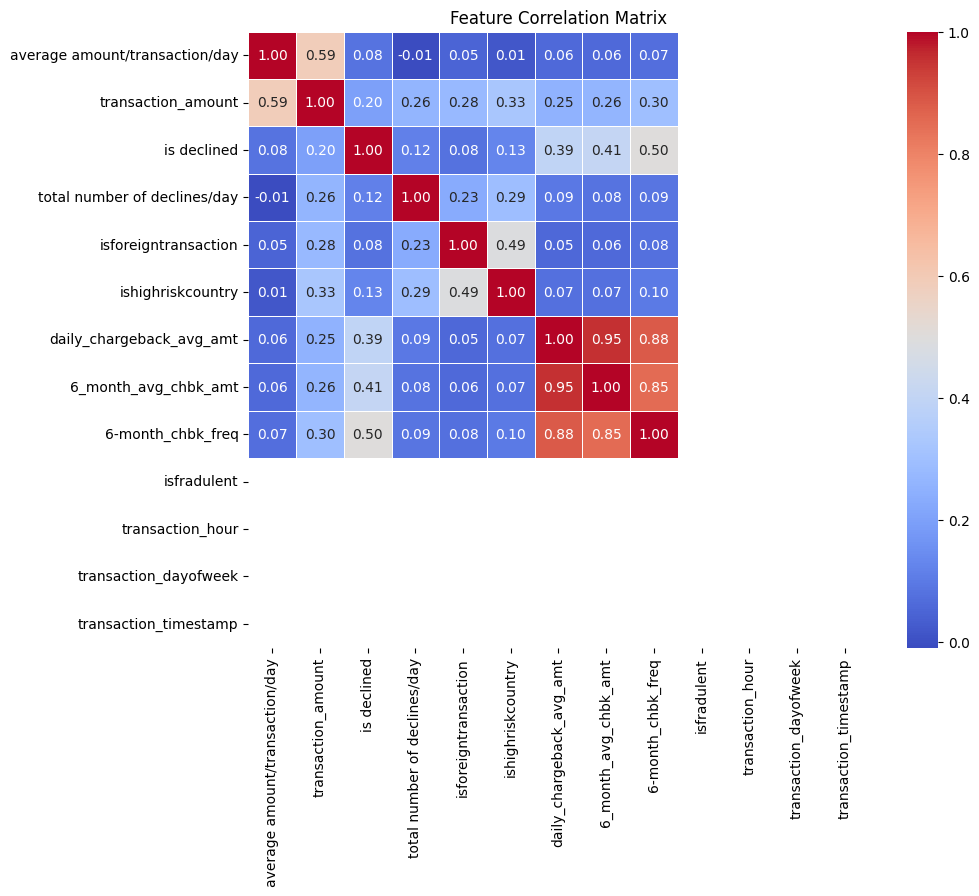

In [654]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 3. Suppression des colonnes non numériques avant le calcul de la corrélation
# Nous excluons les colonnes comme 'merchant_id' (identifiants de marchands) et 'transaction date'
non_numeric_cols = ['merchant_id', 'transaction date']  # Liste des colonnes non numériques
data_numeric = data.drop(columns=non_numeric_cols, errors="ignore")

# 4. Vérification si d'autres colonnes contiennent des valeurs non numériques
for col in data_numeric.columns:
    if data_numeric[col].dtype == 'object':
        print(f"Colonne {col} contient des valeurs non numériques.")
        # Conversion des valeurs restantes en numériques (NaN pour les valeurs non convertibles)
        data_numeric[col] = pd.to_numeric(data_numeric[col], errors='coerce')

# 5. Calcul de la matrice de corrélation
print("Calculating the correlation matrix...")
correlation_matrix = data_numeric.corr()

# 6. Affichage d'un aperçu de la matrice
print("Correlation Matrix (preview):")
print(correlation_matrix.head())

# 7. Visualisation avec une heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()


In [655]:
# # Analyze correlation with the target variable ("Class")
# if 'isfradulent' in correlation_matrix.columns:
#     target_corr = correlation_matrix['isfradulent'].sort_values(ascending=False)
#     print("Correlation with the target variable:")
#     print(target_corr)

#     # Visualize the strongest correlations with the target variable
#     top_features = target_corr[1:11]  # Exclude correlation with itself
#     plt.figure(figsize=(8, 6))
#     sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, dodge=False, palette='viridis', legend=False)
#     plt.title('Top 10 Features Correlated with the Target Variable')
#     plt.xlabel('Correlation Coefficient')
#     plt.ylabel('Features')
#     plt.show()
# else:
#     print("The 'isfradulent' column does not exist in the dataset.")

In [656]:
# Check the range of correlation values
max_corr = correlation_matrix.where(~correlation_matrix.isna()).max().max()
min_corr = correlation_matrix.where(~correlation_matrix.isna()).min().min()

# Lower the threshold for moderate correlations
threshold = 0.9  # Adjust to a lower value
strong_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            strong_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

print(f"Strongly correlated features (>|{threshold}|):")
for pair in strong_corr_pairs:
    print(f"{pair[0]} and {pair[1]} : {pair[2]:.2f}")

Strongly correlated features (>|0.9|):
6_month_avg_chbk_amt and daily_chargeback_avg_amt : 0.95


In [657]:
#smote = SMOTE()
print(type(Y))
print(Y.dtype)
print(np.unique(Y))
pd.Series(Y_train).value_counts()

<class 'numpy.ndarray'>
int64
[0 1]


0    2102
1     358
Name: count, dtype: int64

# Outliers removal

In [658]:
import pandas as pd
from scipy import stats

# Assuming X is a DataFrame and Y is a NumPy array
#Y_series = pd.Series(Y, index=X.index)  # Ensure Y has the same index as X

#z_scores = np.abs(stats.zscore(X))
#threshold = 3
#X_filtered = X[(z_scores < threshold).all(axis=1)]
#y_filtered = Y_series.loc[X_filtered.index]  # Now this will work

In [659]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import IsolationForest

def check_outliers(X, Y, threshold=3, iqr_factor=1.5):
    """
    Check if outliers exist in the dataset (X and Y) using Z-score or IQR.
    Returns True if outliers are detected in either X or Y, False otherwise.
    """
    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)

    # Separate normal and fraudulent transactions
    X_normal = X[Y == 0].select_dtypes(include=['number'])  # Select numeric columns
    Y_normal = Y[Y == 0]
    
    # Ensure Y is a pandas Series
    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)
    
    # Filter only numeric columns for X
    X_numeric = X_normal.select_dtypes(include=['number'])
    
    # Calculate Z-scores for X and Y
    z_scores_X = np.abs(stats.zscore(X_numeric))
    z_scores_Y = np.abs(stats.zscore(Y_normal))
    
    outliers_zscore_X = (z_scores_X > threshold).any().any()
    outliers_zscore_Y = (z_scores_Y > threshold).any()
    
    # Calculate IQR for X and Y
    Q1_X = X_numeric.quantile(0.25)
    Q3_X = X_numeric.quantile(0.75)
    IQR_X = Q3_X - Q1_X
    
    Q1_Y = Y.quantile(0.25)
    Q3_Y = Y.quantile(0.75)
    IQR_Y = Q3_Y - Q1_Y
    
    outliers_iqr_X = ((X_numeric < (Q1_X - iqr_factor * IQR_X)) | (X_numeric > (Q3_X + iqr_factor * IQR_X))).any().any()
    outliers_iqr_Y = ((Y_normal < (Q1_Y - iqr_factor * IQR_Y)) | (Y_normal > (Q3_Y + iqr_factor * IQR_Y))).any()
    
    return outliers_zscore_X or outliers_zscore_Y or outliers_iqr_X or outliers_iqr_Y
    
def remove_outliers(X, Y, method="auto", threshold=3, iqr_factor=1.5, retain_percentage=0.95):
    """
    Removes outliers from normal transactions (class '0.0') while preserving class distribution.
    Ensures a minimum percentage of normal transactions are kept even if they are near the outlier boundary.
    """

    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)

    # Separate normal and fraudulent transactions
    X_normal = X[Y == 0].select_dtypes(include=['number'])  # Select numeric columns
    Y_normal = Y[Y == 0]
    X_fraud = X[Y == 1]
    Y_fraud = Y[Y == 1]

    # Save original class distribution
    original_class_dist = Y.value_counts()

    # Outlier removal: Apply only to the normal class (majority class)
    if method == "auto":
        print("Automatically selecting outlier removal method...")
        if X_normal.std().mean() < threshold:
            print("Using Z-score for outlier removal...")
            X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_zscore(X_normal, Y_normal, threshold)
        else:
            print("Using IQR for outlier removal...")
            X_normal_cleaned = remove_outliers_using_iqr(X_normal, iqr_factor)
            Y_normal_cleaned = Y_normal.loc[X_normal_cleaned.index]

    elif method == "zscore":
        print("Using Z-score for outlier removal...")
        X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_zscore(X_normal, Y_normal, threshold)

    elif method == "iqr":
        print("Using IQR for outlier removal...")
        X_normal_cleaned = remove_outliers_using_iqr(X_normal, iqr_factor)
        Y_normal_cleaned = Y_normal.loc[X_normal_cleaned.index]

    elif method == "isolation_forest":
        print("Using Isolation Forest for outlier removal...")
        X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_if(X_normal, Y_normal)

    # Ensure we retain a minimum percentage of normal transactions
    retained_count = int(len(X_normal) * retain_percentage)
    if len(X_normal_cleaned) < retained_count:
        print(f"Warning: Keeping {retained_count} normal transactions, even if they are outliers.")
        X_normal_cleaned = X_normal.head(retained_count)
        Y_normal_cleaned = Y_normal.head(retained_count)

    # Reunify data while ensuring the class distribution is the same
    X_cleaned = pd.concat([X_normal_cleaned, X_fraud], axis=0).sort_index()
    Y_cleaned = pd.concat([Y_normal_cleaned, Y_fraud], axis=0).sort_index()

    # Check if class distribution remains the same
    new_class_dist = Y_cleaned.value_counts()
    if not original_class_dist.equals(new_class_dist):
        print(f"Warning: Class distribution has changed! Before: {original_class_dist}, After: {new_class_dist}")
    else:
        print("Class distribution is intact before and after outlier removal.")

    return X_cleaned, Y_cleaned

def remove_outliers_using_zscore(X, Y, threshold):
    """
    Removes outliers using the Z-score method.
    """
    z_scores = np.abs(stats.zscore(X))
    X_filtered = X[(z_scores < threshold).all(axis=1)]
    Y_filtered = Y.loc[X_filtered.index]
    return X_filtered, Y_filtered

def remove_outliers_using_iqr(X, iqr_factor=1.5):
    """
    Removes outliers using the IQR method.
    """
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    return X[~((X < (Q1 - iqr_factor * IQR)) | (X > (Q3 + iqr_factor * IQR))).any(axis=1)].copy()

def remove_outliers_using_if(X, Y, contamination=0.05):
    """
    Removes outliers using Isolation Forest.
    """
    model = IsolationForest(contamination=contamination, random_state=42)
    preds = model.fit_predict(X)
    X_filtered = X[preds != -1]  # IsolationForest marks outliers as -1
    Y_filtered = Y.loc[X_filtered.index]
    return X_filtered, Y_filtered

# Example usage:
# X_cleaned, Y_cleaned = remove_outliers(X, Y, method="auto", retain_percentage=0.95)

In [ ]:
# Assuming X is your DataFrame (features) and Y is your Series (target)
outliers_exist = check_outliers(X, Y)
print(f"Outliers detected: {outliers_exist}")

# Step 2: Remove outliers if they exist
if outliers_exist:
    X_filtered, y_filtered = remove_outliers(X, Y, method="auto", threshold=3, iqr_factor=2.0)
    print("Outliers removed.")
else:
    print("No outliers detected. Data is clean.")

print("Cleaned Features (X):")
print(X_filtered)
print("\nCleaned Target (Y):")
print(y_filtered)

Outliers detected: True
Automatically selecting outlier removal method...
Using Z-score for outlier removal...
1     448
Name: count, dtype: int64, After: 0    2495
1     448
Name: count, dtype: int64
Outliers removed.
Cleaned Features (X):
       merchant_id  average amount/transaction/day  transaction_amount  \
0     0.000000e+00                        0.048091            0.027778   
1     0.000000e+00                        0.048091            0.039815   
2     2.561422e-07                        0.090927            0.044657   
3     2.880830e-05                        0.090927            0.046375   
4     5.733079e-05                        0.248493            0.240741   
...            ...                             ...                 ...   
2938  9.541224e-01                        0.302973            0.011273   
2939  9.541248e-01                        0.036540            0.009262   
2940  9.541781e-01                        0.303937            0.045235   
2941  9.561327e-01 

In [661]:
# Check class distribution before SMOTE
#print("Unique classes in y_filtered:", np.unique(y_filtered))
#print("Class distribution in y_filtered:\n", pd.Series(y_filtered).value_counts())

# Stratified split to maintain class balance
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

print("Unique classes in y_train after split:", np.unique(y_train))
print("Class distribution in y_train after split:\n", pd.Series(y_train).value_counts())


Unique classes in y_train after split: [0 1]
Class distribution in y_train after split:
 0    1996
1     358
Name: count, dtype: int64


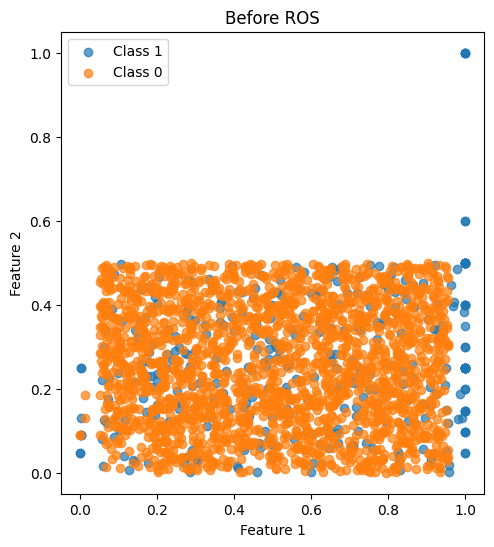

In [662]:
import matplotlib.pyplot as plt
from imblearn.combine import SMOTEENN
from collections import Counter
import numpy as np
import pandas as pd

# -------------------------------
# For visualization, we use only two features.
# If X_train has more than two features, select the first two.
# -------------------------------

# Check if X_train is a DataFrame or a NumPy array and select two columns/features.
if isinstance(X_train, pd.DataFrame):
    if X_train.shape[1] > 2:
        X_vis = X_train.iloc[:, :2]
    else:
        X_vis = X_train.copy()
else:
    # Assuming X_train is a NumPy array
    if X_train.shape[1] > 2:
        X_vis = X_train[:, :2]
    else:
        X_vis = X_train.copy()

# -------------------------------
# Plot Original Data
# -------------------------------
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
# Get unique classes from y_train (works for both NumPy arrays and Series)
classes = np.unique(y_train) if isinstance(y_train, np.ndarray) else y_train.unique()

for cl in classes:
    # Build index mask for the current class
    if isinstance(X_vis, pd.DataFrame):
        idx = (y_train == cl)
        plt.scatter(X_vis.loc[idx, X_vis.columns[0]], 
                    X_vis.loc[idx, X_vis.columns[1]], 
                    label=f'Class {cl}', alpha=0.7)
    else:
        idx = (y_train == cl)
        plt.scatter(X_vis[idx, 0], X_vis[idx, 1], label=f'Class {cl}', alpha=0.7)

plt.title("Before ROS")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()


# ROS oversampling

In [663]:
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
# Apply Random Oversampling
ros = RandomOverSampler(sampling_strategy=0.8, random_state=42)
X_resampled, Y_resampled = ros.fit_resample(X_train, y_train)
data_resampled = pd.concat([pd.DataFrame(X_resampled), pd.Series(Y_resampled, name='Class')], axis=1)

# Display the class distribution after ROS
class_distribution_after = Counter(data_resampled['Class'])
print("Class Distribution After ROS:", class_distribution_after)

Class Distribution After ROS: Counter({0: 1996, 1: 1596})


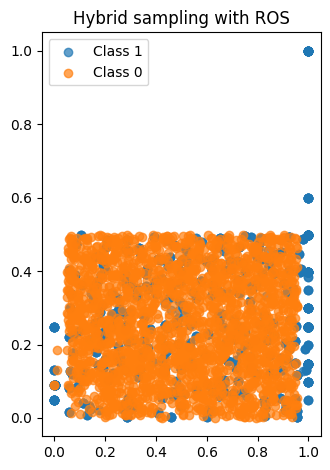

In [664]:
if isinstance(X_resampled, pd.DataFrame):
    if X_resampled.shape[1] > 2:
        X_res_vis = X_resampled.iloc[:, :2]
    else:
        X_res_vis = X_resampled.copy()
else:
    if X_resampled.shape[1] > 2:
        X_res_vis = X_resampled[:, :2]
    else:
        X_res_vis = X_resampled.copy()

# -------------------------------
# Plot Resampled Data
# -------------------------------
plt.subplot(1, 2, 2)
classes_res = np.unique(Y_resampled) if isinstance(Y_resampled, np.ndarray) else Y_resampled.unique()
for cl in classes_res:
    if isinstance(X_res_vis, pd.DataFrame):
        idx = (Y_resampled == cl)
        plt.scatter(X_res_vis.loc[idx, X_res_vis.columns[0]], 
                    X_res_vis.loc[idx, X_res_vis.columns[1]], 
                    label=f'Class {cl}', alpha=0.7)
    else:
        idx = (y_resampled == cl)
        plt.scatter(X_res_vis[idx, 0], X_res_vis[idx, 1], label=f'Class {cl}', alpha=0.7)

plt.title("Hybrid sampling with ROS")
plt.xlabel("")
plt.ylabel("")
plt.legend()

plt.tight_layout()
plt.show()

In [665]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, Y_resampled, train_size = 0.8, test_size = 0.2, random_state = 42,stratify = Y_resampled)

# Feature importance

In [668]:
# Initialize models
models = {
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_estimators=50),
    #"CataBoost": CatBoostClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50)
}

In [669]:
feature_importances = np.zeros(X_resampled.shape[1])
for name, model in models.items():
    # Train the model
    model.fit(X_resampled,Y_resampled)
    if hasattr(model, "feature_importances_"):
        #feature_importances = model.feature_importances_
        feature_importances += model.feature_importances_
        print(f"{name} Feature Importances:\n{model.feature_importances_}")
    else:
        print(f"{name} does not have feature_importances_ attribute.")

Decision Tree Feature Importances:
[0.00277461 0.04834629 0.10705359 0.         0.20727344 0.13843159
 0.27788222 0.         0.03297893 0.18525932 0.         0.
 0.        ]
Random Forest Feature Importances:
[0.03608958 0.06092747 0.16701031 0.00480718 0.22010124 0.17689993
 0.14932882 0.05877031 0.04141271 0.08465243 0.         0.
 0.        ]
Extra Trees Feature Importances:
[0.03039126 0.05209209 0.13610702 0.01728032 0.18025846 0.23522308
 0.15532438 0.06341109 0.04793106 0.08198124 0.         0.
 0.        ]
XGBoost Feature Importances:
[0.00244493 0.01170356 0.01973284 0.         0.07223754 0.4003266
 0.0842765  0.00773603 0.38194287 0.01959912 0.         0.
 0.        ]
AdaBoost Feature Importances:
[0.         0.15690829 0.20717993 0.         0.22096145 0.07215847
 0.14337851 0.03188379 0.         0.16752958 0.         0.
 0.        ]


In [670]:
print(len(models))

5


In [671]:
avg_feature = feature_importances/len(models)

In [672]:
print(data_resampled.columns)


Index(['merchant_id', 'average amount/transaction/day', 'transaction_amount',
       'is declined', 'total number of declines/day', 'isforeigntransaction',
       'ishighriskcountry', 'daily_chargeback_avg_amt', '6_month_avg_chbk_amt',
       '6-month_chbk_freq', 'transaction_hour', 'transaction_dayofweek',
       'transaction_timestamp', 'Class'],
      dtype='object')


In [673]:
feature=(data_resampled.drop(['Class'],axis=1)).columns.values
print ("Features sorted by their score:")
sorted_features = sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True)
sorted_scores, sorted_names = zip(*sorted_features)
cumulative_importance = np.cumsum(sorted_scores)

index = np.where(cumulative_importance >= 0.9)[0][0]
important_features = sorted_names[:index+1]
# Ensure important_features contains the actual column names
important_features = list(important_features)

# Select only the columns corresponding to the important features
X_selected = X_resampled[important_features].values
print(important_features)
print(len(important_features))
print(X_resampled.columns)

Features sorted by their score:
['isforeigntransaction', 'total number of declines/day', 'ishighriskcountry', 'transaction_amount', '6-month_chbk_freq', '6_month_avg_chbk_amt', 'average amount/transaction/day']
7
Index(['merchant_id', 'average amount/transaction/day', 'transaction_amount',
       'is declined', 'total number of declines/day', 'isforeigntransaction',
       'ishighriskcountry', 'daily_chargeback_avg_amt', '6_month_avg_chbk_amt',
       '6-month_chbk_freq', 'transaction_hour', 'transaction_dayofweek',
       'transaction_timestamp'],
      dtype='object')


In [674]:
len(sorted_features)

13

In [675]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, Y_resampled, train_size=0.8, test_size=0.2, random_state=42, stratify=Y_resampled)

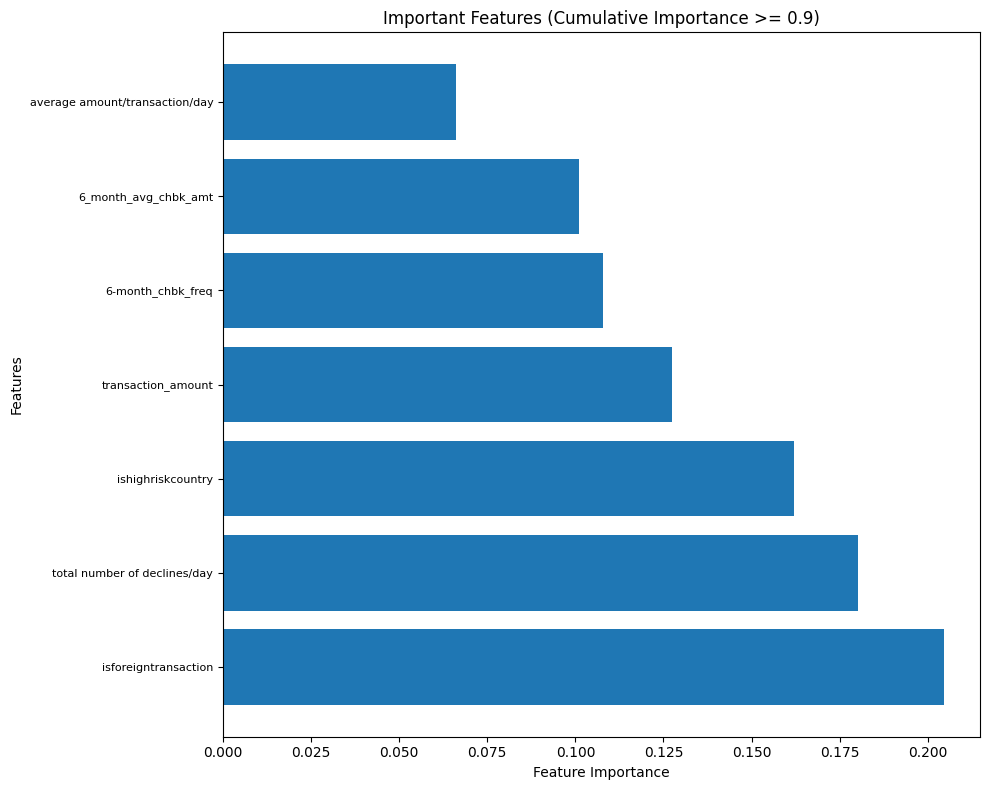

╒════════════════════════════════╤═══════════╕
│ Feature                        │    Weight │
╞════════════════════════════════╪═══════════╡
│ isforeigntransaction           │ 0.215618  │
├────────────────────────────────┼───────────┤
│ total number of declines/day   │ 0.189904  │
├────────────────────────────────┼───────────┤
│ ishighriskcountry              │ 0.170724  │
├────────────────────────────────┼───────────┤
│ transaction_amount             │ 0.134261  │
├────────────────────────────────┼───────────┤
│ 6-month_chbk_freq              │ 0.113605  │
├────────────────────────────────┼───────────┤
│ 6_month_avg_chbk_amt           │ 0.106334  │
├────────────────────────────────┼───────────┤
│ average amount/transaction/day │ 0.0695542 │
╘════════════════════════════════╧═══════════╛


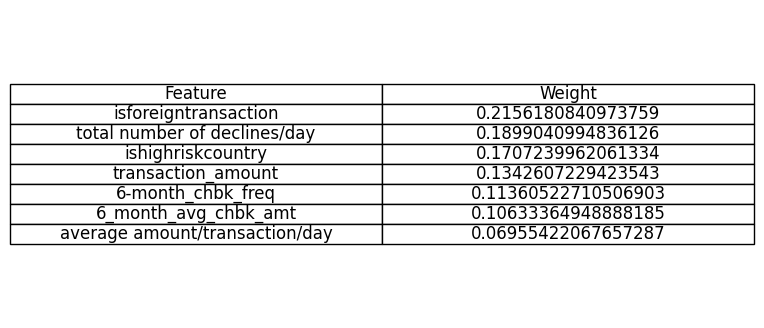

In [676]:
from tabulate import tabulate
# Step 10: Visualize the selected features
plt.figure(figsize=(10, 8))
plt.barh(range(len(important_features)), sorted_scores[:index+1], align='center')
plt.yticks(range(len(important_features)), important_features, fontsize=8)
plt.xlabel('Feature Importance', fontsize=10)
plt.ylabel('Features', fontsize=10)
plt.title('Important Features (Cumulative Importance >= 0.9)', fontsize=12)
plt.tight_layout()
plt.show()

# Step 11: Display the selected features and their weights in a table
important_scores = sorted_scores[:index+1]
total_importance = np.sum(important_scores)
weights = important_scores / total_importance

table_data = [[feature, weight] for feature, weight in zip(important_features, weights)]
headers = ["Feature", "Weight"]

# Print the table
table_str = tabulate(table_data, headers, tablefmt="fancy_grid")
print(table_str)

# Save the table as a PDF
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")
table = ax.table(cellText=table_data, colLabels=headers, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.savefig("feature_importance_table.pdf", bbox_inches="tight")

# GridSearch application

In [677]:
from sklearn.model_selection import GridSearchCV
# Define Parameter Grids for GridSearchCV
param_grid_dt = {'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10]}
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
param_grid_et = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
param_grid_xgb = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.2]}
param_grid_ada = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1]}

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='xgboost')
# Train and Tune Models
def grid_search(model, param_grid, name):
    grid = GridSearchCV(model, param_grid, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], refit='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"Best parameters for {name}: {grid.best_params_}")
    return grid.best_estimator_


best_dt = grid_search(DecisionTreeClassifier(criterion='entropy', random_state=42), param_grid_dt, "Decision Tree")
best_rf = grid_search(RandomForestClassifier(random_state=42), param_grid_rf, "Random Forest")
best_et = grid_search(ExtraTreesClassifier(random_state=42), param_grid_et, "Extra Trees")
best_xgb = grid_search(XGBClassifier(n_estimators=50, eval_metric='logloss'), param_grid_xgb, "XGBoost")
best_ada = grid_search(AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50), param_grid_ada, "AdaBoost")

Best parameters for Decision Tree: {'max_depth': 20, 'min_samples_split': 2}
Best parameters for Random Forest: {'max_depth': 20, 'n_estimators': 100}
Best parameters for Extra Trees: {'max_depth': 20, 'n_estimators': 200}
Best parameters for XGBoost: {'learning_rate': 0.1, 'n_estimators': 200}
Best parameters for AdaBoost: {'learning_rate': 1, 'n_estimators': 200}


# Voting for best results

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

# Step 1: Store Predictions for Meta-Model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_features_train = np.zeros((X_train.shape[0], 5))  # 5 models
meta_features_test = np.zeros((X_test.shape[0], 5))

# Base models
base_models = [
    ('dt', best_dt),
    ('rf', best_rf),
    ('et', best_et),
    ('xgb', best_xgb),
    ('ada', best_ada)
]
y_train = y_train.to_numpy()  # Convert to NumPy array

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    #y_tr, y_val = y_train[train_idx], y_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]


    
    # Train base models and store predictions for meta-model
    for i, (name, model) in enumerate(base_models):
        model.fit(X_tr, y_tr)
        meta_features_train[val_idx, i] = model.predict_proba(X_val)[:, 1]  # Use probabilities

# Fit final models on full training data to predict test meta-features
for i, (name, model) in enumerate(base_models):
    model.fit(X_train, y_train)
    meta_features_test[:, i] = model.predict_proba(X_test)[:, 1]

# Step 2: Define and Tune Voting Classifier with GridSearchCV
voting_clf = VotingClassifier(estimators=base_models, voting='soft')

# Tune Voting Weights Using GridSearchCV
param_grid_voting = {
    'weights': [
        (1, 1, 1, 1, 1),
        (1, 2, 2, 3, 1),
        (2, 1, 1, 1, 2),
        (3, 2, 1, 2, 1),
        (1, 1, 2, 2, 3)
    ]
}

grid_voting = GridSearchCV(voting_clf, param_grid_voting, cv=5, scoring='accuracy', n_jobs=-1)
grid_voting.fit(meta_features_train, y_train)  # Use meta-features for fitting

# Best Voting Classifier with Optimized Weights
best_voting = grid_voting.best_estimator_
print(f"Best Voting Weights: {grid_voting.best_params_}")


Best Voting Weights: {'weights': (1, 2, 2, 3, 1)}


In [ ]:
#print(f"best_voting : {best_voting }")

best_voting : VotingClassifier(estimators=[('dt',
                              DecisionTreeClassifier(criterion='entropy',
                                                     max_depth=20,
                                                     random_state=42)),
                             ('rf',
                              RandomForestClassifier(max_depth=20,
                                                     random_state=42)),
                             ('et',
                              ExtraTreesClassifier(max_depth=20,
                                                   n_estimators=200,
                                                   random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=N...
                

# Second Stage : LSTM predictions

In [681]:
from tensorflow.keras.optimizers import Adam
# Step 3: LSTM Meta-Learner on top of Voting Classifier Predictions
best_voting.fit(X_train, y_train)

# Get Predictions from Voting Classifier (probabilities)
y_pred_voting_train = best_voting.predict_proba(X_train)[:, 1]  # Probabilities of class 1
y_pred_voting_test = best_voting.predict_proba(X_test)[:, 1]  # Probabilities of class 1

# Reshape for LSTM (required shape: [samples, time_steps, features])
X_train_lstm = y_pred_voting_train.reshape(-1, 1, 1)  # Shape (samples, 1, 1)
X_test_lstm = y_pred_voting_test.reshape(-1, 1, 1)  # Shape (samples, 1, 1)

# Convert Labels to Categorical
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# Check the shape of the labels
print("Shape of y_train_cat:", y_train_cat.shape)
print("Shape of y_test_cat:", y_test_cat.shape)

Shape of y_train_cat: (2873, 2)
Shape of y_test_cat: (719, 2)


# Final performance results

# Add autoencoders

In [682]:
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

# Define the Autoencoder
input_shape = (X_train_lstm.shape[1],)  # Adjust input shape based on your data
input_layer = Input(shape=input_shape)

# Encoder
encoded = Dense(256, activation='relu')(input_layer)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.3)(encoded)
encoded = Dense(128, activation='relu')(encoded)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.3)(encoded)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = BatchNormalization()(decoded)
decoded = Dropout(0.3)(decoded)
decoded = Dense(256, activation='relu')(decoded)
decoded = BatchNormalization()(decoded)
decoded = Dropout(0.3)(decoded)
decoded = Dense(input_shape[0], activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train the Autoencoder
autoencoder.fit(X_train_lstm, X_train_lstm,
                epochs=50,
                batch_size=32,
                validation_data=(X_test_lstm, X_test_lstm))

# Print model summary
autoencoder.summary()

# Step 3: Create an Encoder Model for Feature Extraction
encoder = Model(input_layer, encoded)

# Step 4: LSTM Meta-Learner on top of the encoded features
# (Assuming best_voting is a previously trained ensemble model)
y_pred_voting_train = best_voting.predict_proba(X_train)[:, 1]  # Probabilities for class 1
y_pred_voting_test = best_voting.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Convert Labels to Categorical
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# Get the encoded representations (compressed features) for both train and test data
X_train_encoded = encoder.predict(X_train_lstm)
X_test_encoded = encoder.predict(X_test_lstm)

# Check the shape of the categorical labels
print("Shape of y_train_cat:", y_train_cat.shape)
print("Shape of y_test_cat:", y_test_cat.shape)


Epoch 1/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0103 - val_loss: 0.1307
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027 - val_loss: 0.1488
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0026 - val_loss: 0.0223
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024 - val_loss: 8.4167e-04
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0026 - val_loss: 0.0017
Epoch 6/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 7/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023 - val_loss: 0.0033
Epoch 8/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0028 - val_loss: 0.0033
Epoch 9/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0029 - val_loss: 0.0035
Epoch 10/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027 - val_loss: 0.0038
Epoch 11/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0028 - val_loss: 0.0039
Epoch 12/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0022 - va

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255,941 (999.77 KB)

 Trainable params: 84,801 (331.25 KB)

 Non-trainable params: 1,536 (6.00 KB)

 Optimizer params: 169,604 (662.52 KB)

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Shape of y_train_cat: (2873, 2)
Shape of y_test_cat: (719, 2)


In [683]:
X_train_encoded = X_train_encoded[:y_train_cat.shape[0]]
X_test_encoded = X_test_encoded[:y_test_cat.shape[0]]
#print("X_train_encoded shape:", X_train_encoded.shape)
#print("y_train_cat shape:", y_train_cat.shape)
#print("X_test_encoded shape:", X_test_encoded.shape
# Ensure the shape is (samples, time_steps, features) for LSTM
X_train_lstm_ae = X_train_encoded.reshape(X_train_encoded.shape[0], 1, -1)
X_test_lstm_ae = X_test_encoded.reshape(X_test_encoded.shape[0], 1, -1)


In [684]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.metrics import Recall
from tensorflow.keras.regularizers import l2


# Define ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # monitor validation loss
    factor=0.5,            # reduce LR by half
    patience=3,            # wait 3 epochs without improvement
    min_lr=1e-6            # do not go below this LR
)

lstm_model = Sequential([
    #Input(shape=(X_train_lstm_ae.shape[1], X_train_lstm_ae.shape[2])),
    # Première couche LSTM avec régularisation
    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)),  
    BatchNormalization(),
    Dropout(0.5),  
    # Couche dense finale
    Dense(2, activation='softmax', kernel_regularizer=l2(0.001))
])

lstm_model.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-7), loss='categorical_crossentropy', metrics=['accuracy', Recall()])

# Now fit the LSTM Meta-Learner on the reshaped encoded data
history = lstm_model.fit(X_train_lstm_ae, y_train_cat, epochs=30, batch_size=17, validation_data=(X_test_lstm_ae, y_test_cat), callbacks=[reduce_lr])

Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9990 - loss: 0.0594 - recall_10: 0.9990 - val_accuracy: 0.9958 - val_loss: 0.0519 - val_recall_10: 0.9958 - learning_rate: 0.0010
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0246 - recall_10: 1.0000 - val_accuracy: 0.9958 - val_loss: 0.0329 - val_recall_10: 0.9958 - learning_rate: 0.0010
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0171 - recall_10: 1.0000 - val_accuracy: 0.9958 - val_loss: 0.0316 - val_recall_10: 0.9958 - learning_rate: 0.0010
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0130 - recall_10: 1.0000 - val_accuracy: 0.9958 - val_loss: 0.0313 - val_recall_10: 0.9958 - learning_rate: 0.0010
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0104 - recall_10: 1.0000 - val_accuracy: 0.9958 - val_loss: 0.0256 - val_recall_10: 0.9958 - learning_rate: 0.0010
Epoch 6/30
169/169 ━

In [685]:
# LSTM without Autoencoder Model
lstm_model_raw = Sequential([
    #Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    
   # Première couche LSTM avec régularisation
    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)),  
    BatchNormalization(),
    Dropout(0.5),  
    # Couche dense finale
    Dense(2, activation='softmax', kernel_regularizer=l2(0.001))
])

lstm_model_raw.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-7), loss='categorical_crossentropy', metrics=['accuracy', Recall()])

# Train the LSTM Meta-Learner
history_raw = lstm_model_raw.fit(X_train_lstm, y_train_cat, epochs=30, batch_size=17, validation_data=(X_test_lstm, y_test_cat), callbacks=[reduce_lr])#, callbacks=[early_stop], verbose=1)


Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9850 - loss: 0.0975 - recall_11: 0.9850 - val_accuracy: 0.9986 - val_loss: 0.4772 - val_recall_11: 0.9986 - learning_rate: 0.0010
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0135 - recall_11: 1.0000 - val_accuracy: 0.9986 - val_loss: 0.2033 - val_recall_11: 0.9986 - learning_rate: 0.0010
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0103 - recall_11: 1.0000 - val_accuracy: 0.9958 - val_loss: 0.0377 - val_recall_11: 0.9958 - learning_rate: 0.0010
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0093 - recall_11: 1.0000 - val_accuracy: 0.9958 - val_loss: 0.0156 - val_recall_11: 0.9958 - learning_rate: 5.0000e-04
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0089 - recall_11: 1.0000 - val_accuracy: 0.9958 - val_loss: 0.0153 - val_recall_11: 0.9958 - learning_rate: 5.0000e-04
Epoch 6/30
1

In [686]:
# Step 5: Evaluate LSTM Meta-Learner
y_pred_lstm_ae = lstm_model.predict(X_test_lstm_ae)
y_pred_lstm_ae_labels = np.argmax(y_pred_lstm_ae, axis=1)
y_pred_lstm_raw = lstm_model_raw.predict(X_test_lstm)
y_pred_lstm_labels = np.argmax(y_pred_lstm_raw, axis=1)

accuracy_raw = accuracy_score(y_test, np.argmax(y_pred_lstm_raw, axis=1))

# Calculate accuracy of LSTM Meta-Learner
final_accuracy = accuracy_score(y_test, y_pred_lstm_ae_labels)
#print("Final LSTM Meta-Learner Accuracy:", final_accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [687]:
print("Accuracy without Autoencoder:", accuracy_raw)
print("Accuracy with Autoencoder:", final_accuracy)

Accuracy without Autoencoder: 0.9958275382475661
Accuracy with Autoencoder: 0.9986091794158554


Performance without Autoencoder :
Classification report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.99      1.00      1.00       319

    accuracy                           1.00       719
   macro avg       1.00      1.00      1.00       719
weighted avg       1.00      1.00      1.00       719

Accuracy: 0.9958275382475661
Precision : 0.9906832298136646
Recall : 1.0
F1-Score : 0.9953198127925117
F2-Score : 0.9981226533166458
Cohen's Kappa Score : 0.9915558461183122
Matthews Correlation Coefficient (MCC) : 0.9915911988264429
Specificity : 0.9925
G-means : 0.9962429422585638


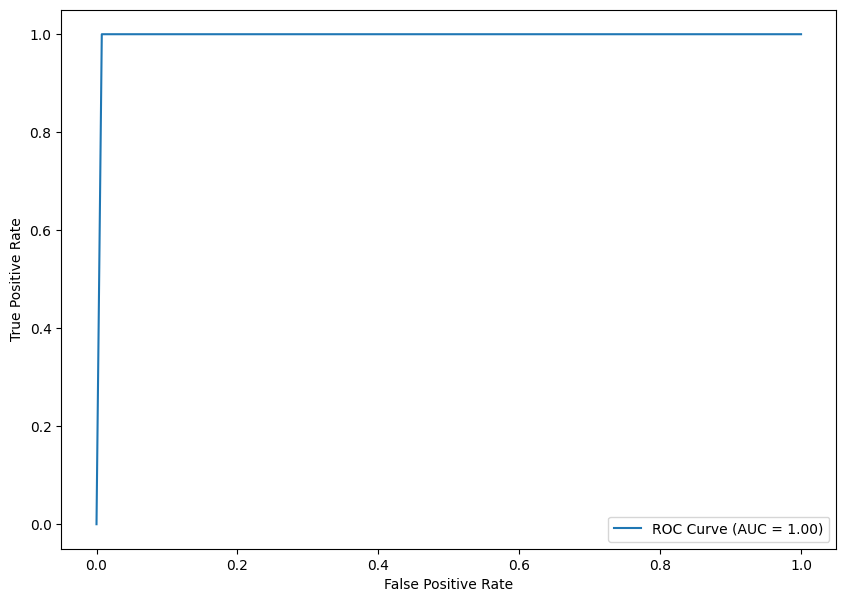

In [688]:
print("Performance without Autoencoder :")

print("Classification report:")
print(classification_report(y_test, y_pred_lstm_labels))
#print("Confusion matrix:")
cm1 = confusion_matrix(y_test, y_pred_lstm_labels)

print("Accuracy:", accuracy_score(y_test, y_pred_lstm_labels))
print("Precision :", precision_score(y_test, y_pred_lstm_labels))
print("Recall :", recall_score(y_test, y_pred_lstm_labels))
print("F1-Score :", f1_score(y_test, y_pred_lstm_labels))

# Compute F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_labels, beta=2)
print("F2-Score :", f2)
print("Cohen's Kappa Score :", cohen_kappa_score(y_test, y_pred_lstm_labels))
print("Matthews Correlation Coefficient (MCC) :", matthews_corrcoef(y_test, y_pred_lstm_labels))
# Calcul de la matrice de confusion
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lstm_labels).ravel()

# Calcul de la sensibilité (rappel)
sensitivity = tp / (tp + fn)

# Calcul de la spécificité
specificity = tn / (tn + fp)
print(f"Specificity : {specificity}")
# Calcul du G-means
g_means = np.sqrt(sensitivity * specificity)
print(f"G-means : {g_means}")
# Calculer l'AUC
#y_proba_trans = y_pred[:, 1]  # Extract probability of class 1
auc_score = roc_auc_score(y_test, y_pred_lstm_labels)

# Calculer les valeurs FPR et TPR pour la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm_labels)

# ROC Curve Data
plt.figure(figsize=(10, 7))

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Confusion matrix Without autoencoder:


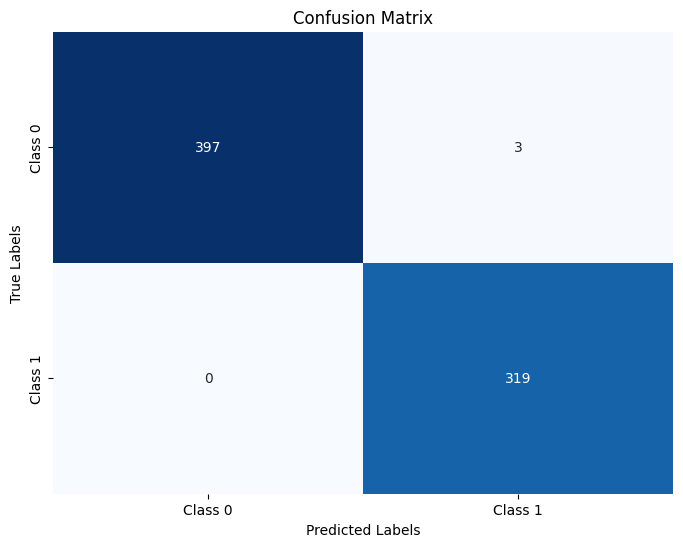

In [689]:
print("Confusion matrix Without autoencoder:")
# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues", cbar=False, 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])

plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Performance with Autoencoder :
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      1.00      1.00       319

    accuracy                           1.00       719
   macro avg       1.00      1.00      1.00       719
weighted avg       1.00      1.00      1.00       719

Accuracy: 0.9986091794158554
Precision : 0.996875
Recall : 1.0
F1-Score : 0.9984350547730829
F2-Score : 0.9993734335839599
Cohen's Kappa Score : 0.9971834958340026
Matthews Correlation Coefficient (MCC) : 0.9971874510341574
Specificity : 0.9975
G-means : 0.998749217771909


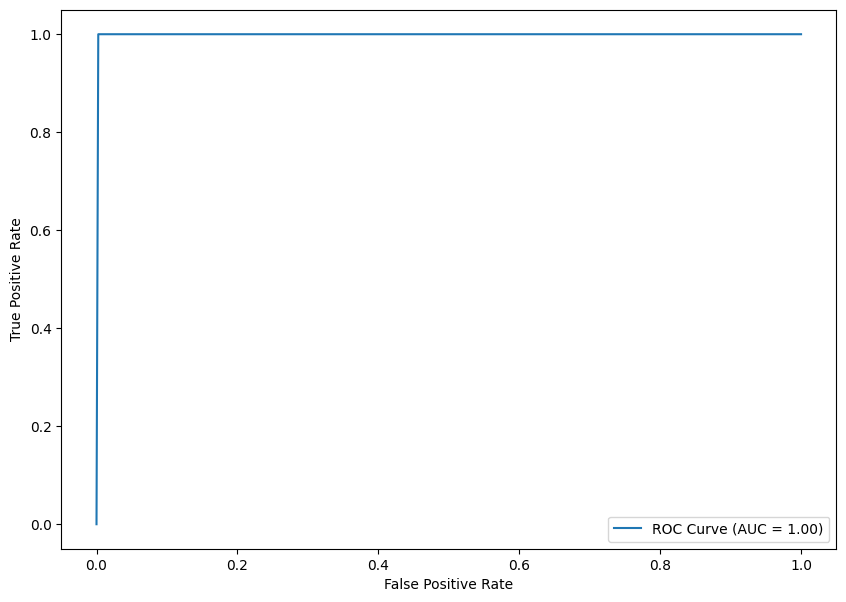

In [690]:
print("Performance with Autoencoder :")

print("Classification report:")
print(classification_report(y_test, y_pred_lstm_ae_labels))
cm = confusion_matrix(y_test, y_pred_lstm_ae_labels)
#print(confusion_matrix(y_test, y_pred_lstm_ae_labels))
print("Accuracy:", accuracy_score(y_test, y_pred_lstm_ae_labels))
print("Precision :", precision_score(y_test, y_pred_lstm_ae_labels))
print("Recall :", recall_score(y_test, y_pred_lstm_ae_labels))
print("F1-Score :", f1_score(y_test, y_pred_lstm_ae_labels))

# Compute F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_ae_labels, beta=2)
print("F2-Score :", f2)
print("Cohen's Kappa Score :", cohen_kappa_score(y_test, y_pred_lstm_ae_labels))
print("Matthews Correlation Coefficient (MCC) :", matthews_corrcoef(y_test, y_pred_lstm_ae_labels))
# Calcul de la matrice de confusion
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lstm_ae_labels).ravel()

# Calcul de la sensibilité (rappel)
sensitivity = tp / (tp + fn)

# Calcul de la spécificité
specificity = tn / (tn + fp)
print(f"Specificity : {specificity}")
# Calcul du G-means
g_means = np.sqrt(sensitivity * specificity)
print(f"G-means : {g_means}")
# Calculer l'AUC
#y_proba_trans = y_pred[:, 1]  # Extract probability of class 1
auc_score = roc_auc_score(y_test, y_pred_lstm_ae_labels)

# Calculer les valeurs FPR et TPR pour la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm_ae_labels)

# ROC Curve Data
plt.figure(figsize=(10, 7))

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Confusion matrix With autoencoder:


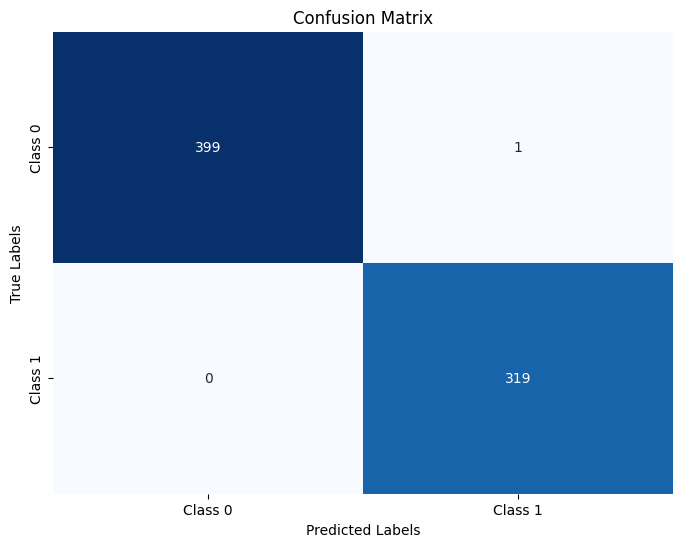

In [691]:
print("Confusion matrix With autoencoder:")
# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])

plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [692]:
import pickle
from tensorflow.keras.models import load_model

# Sauvegarde du modèle avec pickle
with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(lstm_model, f)

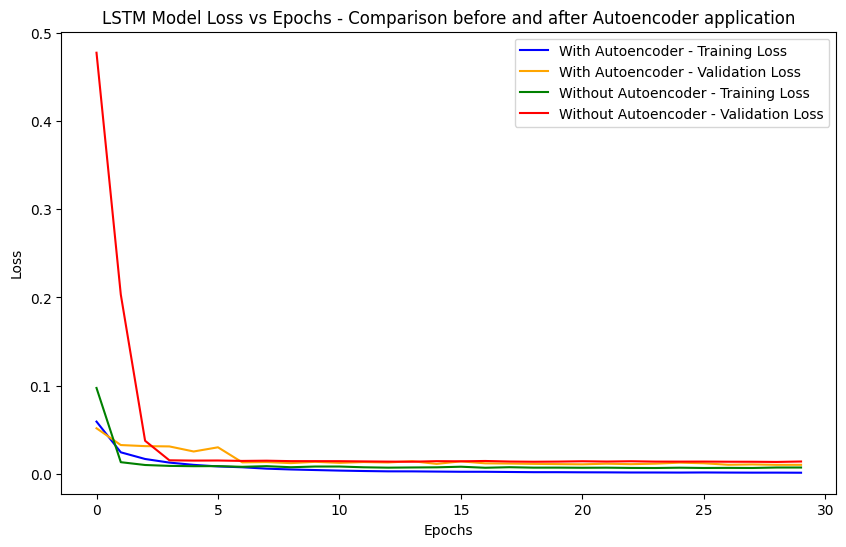

In [693]:
# Extract loss values
train_loss = history.history['loss']  # Training loss for each epoch
val_loss = history.history['val_loss']  # Validation loss for each epoch (if validation data is provided)

train_loss2 = history_raw.history['loss']
val_loss2 = history_raw.history['val_loss']

# Plotting the loss curves for both models
plt.figure(figsize=(10, 6))

# Plot for Model 1
plt.plot(train_loss, label='With Autoencoder - Training Loss', color='blue')
plt.plot(val_loss, label='With Autoencoder - Validation Loss', color='orange')

# Plot for Model 2
plt.plot(train_loss2, label='Without Autoencoder - Training Loss', color='green')
plt.plot(val_loss2, label='Without Autoencoder - Validation Loss', color='red')

# Adding labels and title
plt.title('LSTM Model Loss vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()

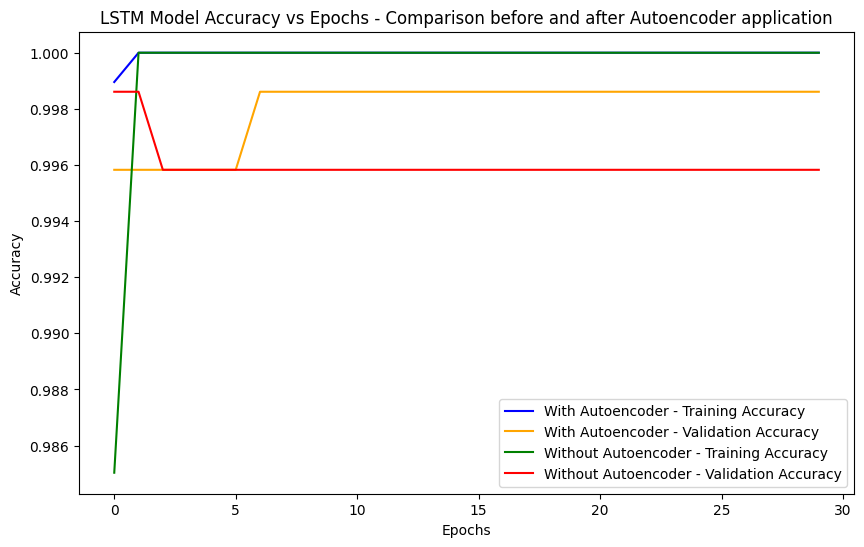

In [694]:
train_acc1 = history.history['accuracy']
val_acc1 = history.history['val_accuracy']

train_acc2 = history_raw.history['accuracy']
val_acc2 = history_raw.history['val_accuracy']

# Plotting accuracy for all models
plt.figure(figsize=(10, 6))
plt.plot(train_acc1, label='With Autoencoder - Training Accuracy', color='blue')
plt.plot(val_acc1, label='With Autoencoder - Validation Accuracy', color='orange')

plt.plot(train_acc2, label='Without Autoencoder - Training Accuracy', color='green')
plt.plot(val_acc2, label='Without Autoencoder - Validation Accuracy', color='red')


plt.title('LSTM Model Accuracy vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

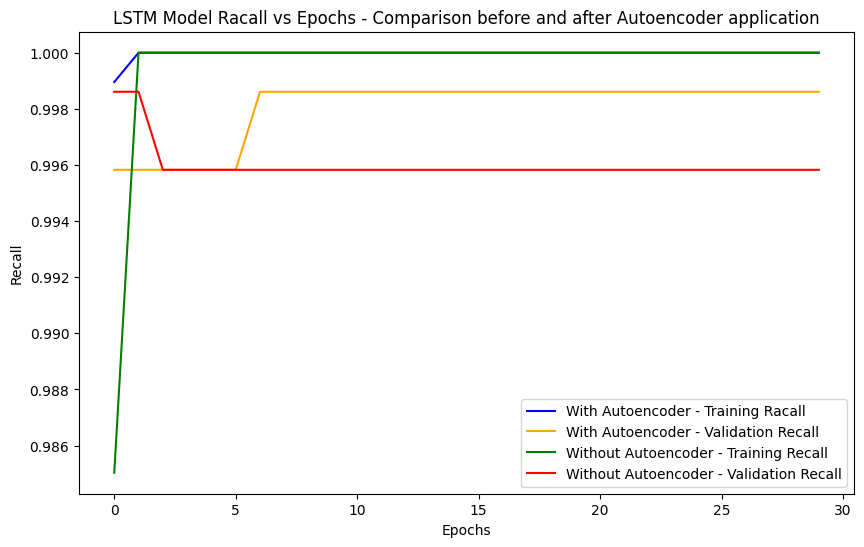

In [ ]:
train_recall1 = history.history['recall_12']
val_recall1 = history.history['val_recall_12']

train_recall2 = history_raw.history['recall_13']
val_recall2 = history_raw.history['val_recall_13']

# Plotting accuracy for all models
plt.figure(figsize=(10, 6))
plt.plot(train_recall1, label='With Autoencoder - Training Racall', color='blue')
plt.plot(val_recall1, label='With Autoencoder - Validation Recall', color='orange')

plt.plot(train_recall2, label='Without Autoencoder - Training Recall', color='green')
plt.plot(val_recall2, label='Without Autoencoder - Validation Recall', color='red')


plt.title('LSTM Model Racall vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.show()

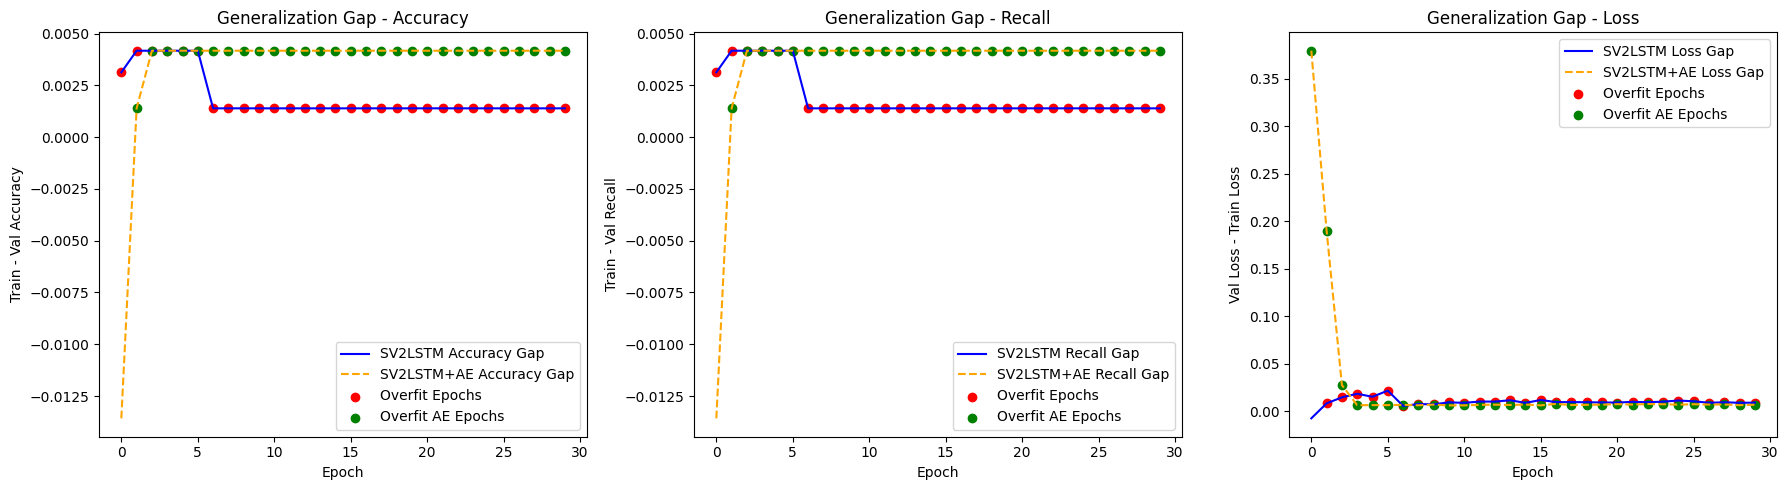

First overfitting epoch (Loss, SV2LSTM): 2
First overfitting epoch (Loss, SV2LSTM+AE): 1
First overfitting epoch (Accuracy, SV2LSTM): 1
First overfitting epoch (Accuracy, SV2LSTM+AE): 2
First overfitting epoch (Recall, SV2LSTM): 1
First overfitting epoch (Recall, SV2LSTM+AE): 2


In [698]:
import numpy as np
import matplotlib.pyplot as plt

# Accuracy and Recall over epochs
train_acc = history.history['accuracy']          # training accuracy per epoch
val_acc   = history.history['val_accuracy']      # validation accuracy per epoch

train_acc_raw = history_raw.history['accuracy']          # training accuracy per epoch
val_acc_raw   = history_raw.history['val_accuracy']      # validation accuracy per epoch


train_recall = history.history['recall_10']
val_recall = history.history['val_recall_10']

train_recall_raw = history_raw.history['recall_11']
val_recall_raw = history_raw.history['val_recall_11']


# Convert to numpy arrays
train_acc = np.array(train_acc)
val_acc   = np.array(val_acc)
train_acc_raw = np.array(train_acc_raw)
val_acc_raw   = np.array(val_acc_raw)

train_recall = np.array(train_recall)
val_recall   = np.array(val_recall)
train_recall_raw = np.array(train_recall_raw)
val_recall_raw   = np.array(val_recall_raw)

train_loss = np.array(history.history['loss'])
val_loss   = np.array(history.history['val_loss'])
train_loss2 = np.array(history_raw.history['loss'])
val_loss2   = np.array(history_raw.history['val_loss'])

# Compute generalization gaps
acc_gap = train_acc - val_acc
acc_gap_raw = train_acc_raw - val_acc_raw

recall_gap = train_recall - val_recall
recall_gap_raw = train_recall_raw - val_recall_raw

loss_gap = val_loss - train_loss
loss_gap_raw = val_loss2 - train_loss2

# Identify overfitting epochs
overfit_loss_epochs = np.where(loss_gap > 0)[0]
overfit_loss_epochs_raw = np.where(loss_gap_raw > 0)[0]

overfit_acc_epochs = np.where(acc_gap > 0)[0]
overfit_acc_epochs_raw = np.where(acc_gap_raw > 0)[0]

overfit_recall_epochs = np.where(recall_gap > 0)[0]
overfit_recall_epochs_raw = np.where(recall_gap_raw > 0)[0]

# Plotting
plt.figure(figsize=(18,5))

# Accuracy gap
plt.subplot(1,3,1)
plt.plot(acc_gap, label='SV2LSTM Accuracy Gap', color='blue', linestyle='-')
plt.plot(acc_gap_raw, label='SV2LSTM+AE Accuracy Gap', color='orange', linestyle='--')
plt.scatter(overfit_acc_epochs, acc_gap[overfit_acc_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_acc_epochs_raw, acc_gap_raw[overfit_acc_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Train - Val Accuracy')
plt.grid(False)
plt.legend()

# Recall gap
plt.subplot(1,3,2)
plt.plot(recall_gap, label='SV2LSTM Recall Gap', color='blue', linestyle='-')
plt.plot(recall_gap_raw, label='SV2LSTM+AE Recall Gap', color='orange', linestyle='--')
plt.scatter(overfit_recall_epochs, recall_gap[overfit_recall_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_recall_epochs_raw, recall_gap_raw[overfit_recall_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Recall')
plt.xlabel('Epoch')
plt.ylabel('Train - Val Recall')
plt.grid(False)
plt.legend()

# Loss gap
plt.subplot(1,3,3)
plt.plot(loss_gap, label='SV2LSTM Loss Gap', color='blue')
plt.plot(loss_gap_raw, label='SV2LSTM+AE Loss Gap', color='orange', linestyle='--')
plt.scatter(overfit_loss_epochs, loss_gap[overfit_loss_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_loss_epochs_raw, loss_gap_raw[overfit_loss_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Loss')
plt.xlabel('Epoch')
plt.ylabel('Val Loss - Train Loss')
plt.grid(False)
plt.legend()

plt.tight_layout()
# Save the figure
plt.savefig("SV2LSTM_SCD_ROS_generalization_gap.png", dpi=300)  # high-resolution PNG
plt.show()

# Optional: print first overfitting epoch for each metric
if len(overfit_loss_epochs) > 0:
    print(f"First overfitting epoch (Loss, SV2LSTM): {overfit_loss_epochs[0]+1}")
if len(overfit_loss_epochs_raw) > 0:
    print(f"First overfitting epoch (Loss, SV2LSTM+AE): {overfit_loss_epochs_raw[0]+1}")
if len(overfit_acc_epochs) > 0:
    print(f"First overfitting epoch (Accuracy, SV2LSTM): {overfit_acc_epochs[0]+1}")
if len(overfit_acc_epochs_raw) > 0:
    print(f"First overfitting epoch (Accuracy, SV2LSTM+AE): {overfit_acc_epochs_raw[0]+1}")
if len(overfit_recall_epochs) > 0:
    print(f"First overfitting epoch (Recall, SV2LSTM): {overfit_recall_epochs[0]+1}")
if len(overfit_recall_epochs_raw) > 0:
    print(f"First overfitting epoch (Recall, SV2LSTM+AE): {overfit_recall_epochs_raw[0]+1}")
